<a href="https://colab.research.google.com/github/harsh0309/Machine-Learning-Projects/blob/main/LinearRegression_cali_house.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
df=fetch_california_housing()

In [5]:
dataset=pd.DataFrame(df.data)

In [6]:
dataset.columns=df.feature_names

In [7]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
##Independent features and Dependent features
X=dataset
y=df.target

In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [11]:
#standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [12]:
scaler.fit(X_train)

StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [14]:
scaler.inverse_transform(X_test)

array([[   4.1518    ,   22.        ,    5.66307278, ...,    4.18059299,
          32.58      , -117.05      ],
       [   5.7796    ,   32.        ,    6.10722611, ...,    3.02097902,
          33.92      , -117.97      ],
       [   4.3487    ,   29.        ,    5.93071161, ...,    2.91011236,
          38.65      , -121.84      ],
       ...,
       [   7.875     ,   30.        ,    7.55092593, ...,    2.4212963 ,
          33.89      , -117.91      ],
       [   2.0658    ,   34.        ,    5.93814433, ...,    3.74226804,
          36.56      , -119.64      ],
       [   4.6761    ,   32.        ,    5.31515152, ...,    2.77878788,
          37.36      , -121.99      ]])

In [15]:
from sklearn.linear_model import LinearRegression
##cross validation
from sklearn.model_selection import cross_val_score

In [16]:
regression=LinearRegression()
regression.fit(X_train,y_train)


LinearRegression()

In [18]:
mse=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=5)

In [19]:
np.mean(mse)

np.float64(-0.5223169754935085)

In [20]:
##predicttion
reg_pred=regression.predict(X_test)

In [21]:
reg_pred

array([2.2702672 , 2.79059912, 1.90984782, ..., 3.56895295, 0.98163812,
       2.72552317])

/tmp/ipykernel_3863/3835018317.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-reg_pred)


<Axes: ylabel='Density'>

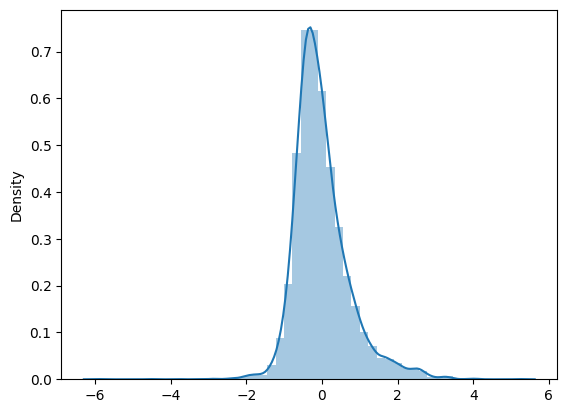

In [22]:
import seaborn as sns
sns.distplot(y_test-reg_pred)

In [23]:
from  sklearn.metrics import r2_score
r2_score(y_test,reg_pred)

0.5926087785518777